# 最短路算法

从 $v_3$ 到其他所有其余顶点的最短路及最短距离

$$
\bodsymbol{W} = 
\begin{bmatrix}
0 & 1 & 2 & \infty & 7 & \infty & 4 & 8 \\
1 & 0 & 2 & 3 & \infty & \infty & \infty & 7 \\
2 & 2 & 0 & 1 & 5 & \infty & \infty & \infty \\
\infty & 3 & 1 & 0 & 3 & 6 & \infty & \infty \\
7 & \infty & 5 & 3 & 0 & 4 & 3 & \infty \\
\infty & \infty & \infty & 6 & 4 & 0 & 6 & 4 \\
4 & \infty & \infty & \infty & 3 & 6 & 0 & 2 \\
8 & 7 & \infty & \infty & \infty & 4 & 2 & 0 \\
\end{bmatrix}
$$

2: 3->2
0: 3->2->0
1: 3->1
4: 3->4
5: 3->5
6: 3->4->6
7: 3->4->6->7
v3到所有顶点的最短距离为: [3, 3, 1, 0, 3, 6, 6, 8]


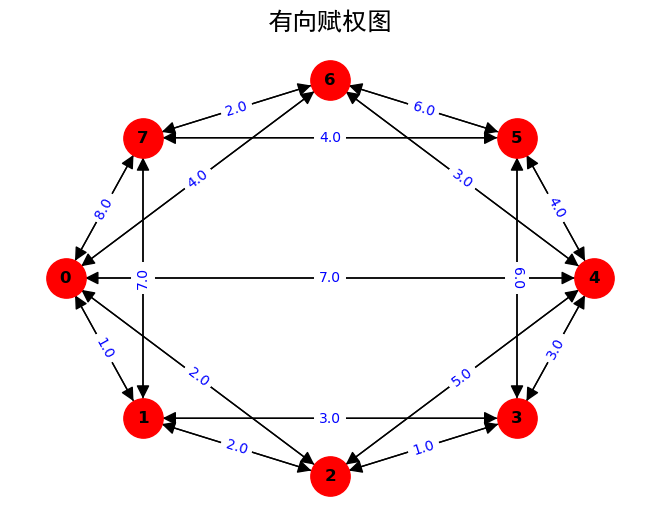

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

inf = np.inf

# Dijkstra 算法函数
def Dijkstra_all_minpath(matr, start):  # matr为邻接矩阵的数组，start表示起点
    n = len(matr)  # 该图的节点数, n=8
    dis = []  # 存最短距离distance
    temp = []  # 临时距离表，用于找最小值
    dis.extend(matr[start])  # 添加数组matr的start行元素（即第4行[inf, 3, 1, 0, 3, 6, inf, inf]）
    temp.extend(matr[start])  # 添加矩阵matr的start行元素（即第4行）
    temp[start] = inf  # 临时数组会把处理过的节点的值变成inf(temp=[inf, 3, 1, inf, 3, 6, inf, inf]
    visited = [start]  # start 已处理  visited=[3]
    parent = [start] * n  # parent=[3, 3, 3, 3, 3, 3, 3, 3] 扩展成1x8向量，方便之后填入父节点
    while len(visited) < n:  # 算法终止条件，将所有的点放入visited
        i = temp.index(min(temp))  # 找v3到vi的最短路，i=2,第二次迭代temp=[3, 3, inf, inf, 3, 6, inf, inf], i=0
        temp[i] = inf  # temp=[inf, 3, inf, inf, 3, 6, inf, inf]，终点为vi，temp对应的temp[i-1]变成inf
        for j in range(n):  # n=8
            if j not in visited:  # visited=[3]
                # d[i]——v3到相邻点的最短距离，dis[i]+matr[i][j]——v3经过v2到其他相邻点的距离，d[j]——v3直接到对应相邻点的距离
                if (dis[i] + matr[i][j]) < dis[j]:  # matr[2][j]该行逐个元素(即下图2点与相邻点的距离)
                    dis[j] = temp[j] = dis[i] + matr[i][j]  # 如果小于，将从v3经过v2的距离加入dis(v3与其他点的最短距离)的对应位置(该索引为0,即dis的第一个位置变为0)即dis=temp=[3, 3, 1, 0, 3, 6, inf, inf]
                    parent[j] = i  # 更新父节点，现在是2(v2),parent=[2, 3, 3, 3, 3, 3, 3, 3]
        visited.append(i)  # 将处理过的i放入visited,visited=[3, 2]
        path = []  # 用于画路径
        path.append(str(i))  # 将i转换成字符串加入path
        k = i
        while(parent[k] != start):  # 找该节点的父节点添加到path,直到父节点是start
            path.append(str(parent[k]))
            k = parent[k]  # 迭代，以该父节点为k，寻找该父节点的上一个父节点
        path.append(str(start))  # 最后将起点start加入path
        path.reverse()  # path反序，产生路径
        print(f"{str(i)}: {'->'.join(path)}")  # 输出路径
    return dis

a = [[0, 1, 2, inf, 7, inf, 4, 8],
     [1, 0, 2, 3, inf, inf, inf, 7],
     [2, 2, 0, 1, 5, inf, inf, inf],
     [inf, 3, 1, 0, 3, 6, inf, inf],
     [7, inf, 5, 3, 0, 4, 3, inf], 
     [inf, inf, inf, 6, 4, 0, 6, 4],
     [4, inf, inf, inf, 3, 6, 0, 2], 
     [8, 7, inf, inf, inf, 4, 2, 0]]
d = Dijkstra_all_minpath(a, 3)

print(f"v3到所有顶点的最短距离为: {d}")

# G = nx.DiGraph(a)  # 报错：nx.DiGraph(a) 直接把 邻接矩阵 当成“邻接列表”解释，会把 inf 当成有效权重，产生大量 inf 权重的边
adj = np.array(a, dtype=float)          # 把 list a 转成 ndarray
G = nx.from_numpy_array(adj, create_using=nx.DiGraph)  # 有向图
# 去掉权重为 inf 的边（权重属性仍保留）
G.remove_edges_from([(u, v) for u, v, w in G.edges(data='weight') if np.isinf(w)])

# 4. 画图
plt.rcParams['font.size'] = 15
plt.rcParams['font.family'] = ['SimHei']
pos = nx.shell_layout(G)           # 节点布局
edge_labels = nx.get_edge_attributes(G, 'weight')  # 取出权重

nx.draw(G, pos,
        with_labels=True,
        node_color='r',
        node_size=800,
        font_weight='bod',
        arrows=True,              # 有向图箭头
        arrowsize=20)

nx.draw_networkx_edge_labels(G, pos,
                             edge_labels=edge_labels,
                             font_color='b')

plt.title("有向赋权图")
plt.show()

networkx 求所有顶点对之间**最短路径**的函数为  
### 1. shortest_path(G, source=None, target=None, weight=None, method='dijkstra')(单源，使用双索引会有未来警告)  
返回值是可迭代类型，其中 method 可以取值'dijkstra','bellman-ford'.

networkx 求所有顶点对之间**最短距离**的函数为
### 2. shortest_path_length(G, source=None, target=None, weight=None, method='dijkstra')(单源，使用双索引会有未来警告)  
返回值是可迭代类型，其中 method 可以取值'dijkstra','bellman-ford'

最短路径(全源)  
#### 1. from networkx.algorithms.shortest_paths import (
    all_pairs_dijkstra_path  # 迪杰斯特拉算法
    all_pairs_bellman_ford_path  # 贝尔曼福特算法
)   调用格式一样

最短距离(全源)   
#### 2.from networkx.algorithms.shortest_paths import (
    all_pairs_dijkstra_path_length  # 迪杰斯特拉算法
    all_pairs_bellman_ford_path_length  # 贝尔曼福特算法
)   调用格式一样

## 3. Floyd-Warshall算法

### (1) nx.floyd_warshall_predecessor_and_distance(G, weight='weight')

| 参数     | 类型         | 默认值      | 说明                                        |
| ------ | ---------- | -------- | ----------------------------------------- |
| G      | NetworkX 图 | 必填       | 任意 DiGraph / Graph / MultiGraph 等         |
| weight | str 或 func | 'weight' | 边权字段名，或形如 `lambda u, v, d: d['cost']` 的函数 |

返回值  
(pred, dist) 二元组  
pred：dict-of-dict，类型同 dist  
pred[u][v] 是 u→v 最短路径上的倒数第二个节点（可用于回溯整条路径）。  
dist：dict-of-dict  
dist[u][v] 给出 u→v 的最短距离；不可达为 float('inf')  

### (2) nx.floyd_warshall_numpy(G, nodelist=None, weight='weight')

| 参数       | 类型         | 默认值      | 说明                             |
| -------- | ---------- | -------- | ------------------------------ |
| G        | NetworkX 图 | 必填       | 同上                             |
| nodelist | list       | None     | 指定节点顺序；None 时用 `G.nodes()` 的顺序 |
| weight   | str 或 func | 'weight' | 同上                             |

返回值
dist_matrix：NumPy ndarray，形状 (len(nodelist), len(nodelist))
元素 dist_matrix[i, j] 即 nodelist[i] → nodelist[j] 的最短距离；不可达为 np.inf

In [ ]:
# 求上图所有顶点之间的最短距离
import numpy as np

def floyd(graph):
    m = len(graph)
    dis = graph
    path = np.zeros((m, m))  # 路由矩阵初始化
    # 迭代次数为k时，每i行的第k+1(索引为k)个元素(dis[i][k])+第k+1行的每一个元素(dis[k][j])之和 < = > 第i行的每一个元素比大小
    for k in range(m):  # 每次更新的k即为第k个顶点，看经过该顶点时是否比直接到达更近(对每个元素)，更近则替换
        for i in range(m):
            for j in range(m):
                if (dis[i][k] + dis[k][j]) < dis[i][j]:
                    dis[i][j] = dis[i][k] + dis[k][j]
                    path[i][j] = k  # 中转站更近就将中转站k(顶点v_k+1)写入路由矩阵
    return dis, path

inf = np.inf
a = [[0, 1, 2, inf, 7, inf, 4, 8],
     [1, 0, 2, 3, inf, inf, inf, 7],
     [2, 2, 0, 1, 5, inf, inf, inf],
     [inf, 3, 1, 0, 3, 6, inf, inf],
     [7, inf, 5, 3, 0, 4, 3, inf], 
     [inf, inf, inf, 6, 4, 0, 6, 4],
     [4, inf, inf, inf, 3, 6, 0, 2], 
     [8, 7, inf, inf, inf, 4, 2, 0]]
dis, path = floyd(a)

print(f"所有顶点对之间的最短距离为:\n{dis}\n路由矩阵为:\n{path}")

所有顶点对之间的最短距离为:
[[0, 1, 2, 3, 6, 9, 4, 6], [1, 0, 2, 3, 6, 9, 5, 7], [2, 2, 0, 1, 4, 7, 6, 8], [3, 3, 1, 0, 3, 6, 6, 8], [6, 6, 4, 3, 0, 4, 3, 5], [9, 9, 7, 6, 4, 0, 6, 4], [4, 5, 6, 6, 3, 6, 0, 2], [6, 7, 8, 8, 5, 4, 2, 0]]
路由矩阵为:
[[0. 0. 0. 2. 3. 3. 0. 6.]
 [0. 0. 0. 0. 3. 3. 0. 0.]
 [0. 0. 0. 0. 3. 3. 0. 6.]
 [2. 0. 0. 0. 0. 0. 4. 6.]
 [3. 3. 3. 0. 0. 0. 0. 6.]
 [3. 3. 3. 0. 0. 0. 0. 0.]
 [0. 0. 0. 4. 0. 0. 0. 0.]
 [6. 0. 6. 6. 6. 0. 0. 0.]]


In [ ]:
# 直接使用network中的函数求两个顶点之间最短距离和最短路径
import numpy as np
import networkx as nx

a = np.loadtxt("Pdata10_6.txt")
G = nx.Graph(a)  # 利用邻接矩阵构造赋权无向图

# 当G为多个元组组成的列表时，不会有警告(u, v, weight)
d = dict(nx.shortest_path_length(G, weight='weight'))  # d为可迭代类型

print(f"顶点对之间的距离为:\n{d}")  # 显示所有顶点之间的最短距离
print(f"顶点0到定点4的最短距离为:\n{d[0][4]}")  # 显示一对顶点之间的最短距离

m, n = a.shape
dd = np.zeros((m, n))

for i in range(m):
    for j in range(n):
        dd[i, j] = d[i][j]
        
print(f"顶点对之间最短距离的数组表示为:\n{dd}")  # 显示所有顶点之间的最短距离

np.savetxt('Pdata10_8.txt', dd)  # 把最短距离数组保存到文本文件中

p = dict(nx.shortest_path(G, weight='weight'))  # p为可迭代类型

print(f"顶点对之间的最短路径为:\n{p}")
print(f"顶点0到顶点4的最短路径为:{p[0][4]}")
print()

顶点对之间的距离为:
{0: {0: 0, 1: 1.0, 2: 2.0, 3: 3.0, 6: 4.0, 4: 6.0, 7: 6.0, 5: 9.0}, 1: {1: 0, 0: 1.0, 2: 2.0, 3: 3.0, 6: 5.0, 4: 6.0, 7: 7.0, 5: 9.0}, 2: {2: 0, 3: 1.0, 0: 2.0, 1: 2.0, 4: 4.0, 6: 6.0, 5: 7.0, 7: 8.0}, 3: {3: 0, 2: 1.0, 1: 3.0, 4: 3.0, 0: 3.0, 5: 6.0, 6: 6.0, 7: 8.0}, 4: {4: 0, 3: 3.0, 6: 3.0, 5: 4.0, 2: 4.0, 7: 5.0, 1: 6.0, 0: 6.0}, 5: {5: 0, 4: 4.0, 7: 4.0, 3: 6.0, 6: 6.0, 2: 7.0, 1: 9.0, 0: 9.0}, 6: {6: 0, 7: 2.0, 4: 3.0, 0: 4.0, 1: 5.0, 5: 6.0, 3: 6.0, 2: 6.0}, 7: {7: 0, 6: 2.0, 5: 4.0, 4: 5.0, 0: 6.0, 1: 7.0, 3: 8.0, 2: 8.0}}
顶点0到定点4的最短距离为:
6.0
顶点对之间最短距离的数组表示为:
[[0. 1. 2. 3. 6. 9. 4. 6.]
 [1. 0. 2. 3. 6. 9. 5. 7.]
 [2. 2. 0. 1. 4. 7. 6. 8.]
 [3. 3. 1. 0. 3. 6. 6. 8.]
 [6. 6. 4. 3. 0. 4. 3. 5.]
 [9. 9. 7. 6. 4. 0. 6. 4.]
 [4. 5. 6. 6. 3. 6. 0. 2.]
 [6. 7. 8. 8. 5. 4. 2. 0.]]
顶点对之间的最短路径为:
{0: {0: [0], 1: [0, 1], 2: [0, 2], 4: [0, 2, 3, 4], 6: [0, 6], 7: [0, 6, 7], 3: [0, 2, 3], 5: [0, 2, 3, 5]}, 1: {1: [1], 0: [1, 0], 2: [1, 2], 3: [1, 3], 7: [1, 7], 4: [1, 3, 4], 6: [1, 

<class 'networkx.utils.decorators.argmap'> compilation 32:3: FutureWarning: 

shortest_path will return an iterator that yields
(node, path) pairs instead of a dictionary when source
and target are unspecified beginning in version 3.5

To keep the current behavior, use:

	dict(nx.shortest_path(G))
  import gzip


In [ ]:
# 不触发未来警告
import numpy as np
from networkx.algorithms.shortest_paths import all_pairs_dijkstra_path, all_pairs_dijkstra_path_length

a = np.loadtxt("Pdata10_6.txt")
G = nx.Graph(a)  # 利用黄金零矩阵构造赋权无向图

d = dict(all_pairs_dijkstra_path_length(G, weight='weight'))  # 先返回一个可迭代类型数据，后转化为字典

print(f"顶点对之间的距离为:\n{d}")  # 显示所有顶点之间的最短距离
print(f"顶点0到定点4的最短距离为:\n{d[0][4]}")  # 显示一对顶点之间的最短距离

m, n = a.shape
dd = np.zeros((m, n))

# 将字典转化为数组
for i in range(m):
    for j in range(n):
        dd[i, j] = d[i][j]
        
print(f"顶点对之间最短距离的数组表示为:\n{dd}")  # 显示所有顶点之间的最短距离

np.savetxt('Pdata10_8.txt', dd)  # 把最短距离数组保存到文本文件中

p = dict(all_pairs_dijkstra_path(G, weight='weight'))  # 先返回一个可迭代类型数据，后转化为字典

print(f"顶点对之间的最短路径为:\n{p}")
print(f"顶点0到顶点4的最短路径为:{p[0][4]}")
print()

顶点对之间的距离为:
{0: {0: 0, 1: 1.0, 2: 2.0, 3: 3.0, 6: 4.0, 4: 6.0, 7: 6.0, 5: 9.0}, 1: {1: 0, 0: 1.0, 2: 2.0, 3: 3.0, 6: 5.0, 4: 6.0, 7: 7.0, 5: 9.0}, 2: {2: 0, 3: 1.0, 0: 2.0, 1: 2.0, 4: 4.0, 6: 6.0, 5: 7.0, 7: 8.0}, 3: {3: 0, 2: 1.0, 1: 3.0, 4: 3.0, 0: 3.0, 5: 6.0, 6: 6.0, 7: 8.0}, 4: {4: 0, 3: 3.0, 6: 3.0, 5: 4.0, 2: 4.0, 7: 5.0, 1: 6.0, 0: 6.0}, 5: {5: 0, 4: 4.0, 7: 4.0, 3: 6.0, 6: 6.0, 2: 7.0, 1: 9.0, 0: 9.0}, 6: {6: 0, 7: 2.0, 4: 3.0, 0: 4.0, 1: 5.0, 5: 6.0, 3: 6.0, 2: 6.0}, 7: {7: 0, 6: 2.0, 5: 4.0, 4: 5.0, 0: 6.0, 1: 7.0, 3: 8.0, 2: 8.0}}
顶点0到定点4的最短距离为:
6.0
顶点对之间最短距离的数组表示为:
[[0. 1. 2. 3. 6. 9. 4. 6.]
 [1. 0. 2. 3. 6. 9. 5. 7.]
 [2. 2. 0. 1. 4. 7. 6. 8.]
 [3. 3. 1. 0. 3. 6. 6. 8.]
 [6. 6. 4. 3. 0. 4. 3. 5.]
 [9. 9. 7. 6. 4. 0. 6. 4.]
 [4. 5. 6. 6. 3. 6. 0. 2.]
 [6. 7. 8. 8. 5. 4. 2. 0.]]
顶点对之间的最短路径为:
{0: {0: [0], 1: [0, 1], 2: [0, 2], 4: [0, 2, 3, 4], 6: [0, 6], 7: [0, 6, 7], 3: [0, 2, 3], 5: [0, 2, 3, 5]}, 1: {1: [1], 0: [1, 0], 2: [1, 2], 3: [1, 3], 7: [1, 7], 4: [1, 3, 4], 6: [1, 

### 1. 设备更新问题（可能有负权，常用Floyd） 

某种工程设备的役龄为 4 年，每年年初都面临着是否更新的问题：若卖旧买新，就要支付一定的购置费用；若继续使用，则要支付更多的维护费用，且使用年限越长维护费用越多。若役龄期内每年的年初购置价格、当年维护费用及年末剩余净值如表 10.1 所示。请为该设备制订一个 4 年役龄期内的更新计划，使总的支付费用最少。

#### 表 10.1 相关费用数据
|年份|1|2|3|4|
| ---- | ---- | ---- | ---- | ---- |
|年初购置价格/万元|25|26|28|31|
|当年维护费用/万元|10|14|18|26|
|年末剩余净值/万元|20|16|13|11|

#### 解  
可以把这个问题化为图论中的最短路问题。

构造赋权有向图 $D = (V, A, W)$，其中顶点集 $V = \{v_1, v_2, \cdots, v_5\}$，这里 $v_i (i = 1,2,3,4)$ 表示第 $i$ 年年初的时刻，$v_5$ 表示第 4 年年末的时刻，$A$ 为弧的集合，邻接矩阵 $\boldsymbol{W} = (w_{ij})_{5 \times 5}$，这里 $w_{ij}$ 为第 $i$ 年年初至第 $j$ 年年初（或 $j - 1$ 年年末）期间所支付的费用，计算公式为：  
$$
w_{ij} = p_i + \sum_{k=1}^{j-i} a_k - r_{j-i}
$$  
其中：  
- $p_i$ 为第 $i$ 年年初的购置价格  
- $a_k$ 为使用到第 $k$ 年当年的维护费用  
- $r_i$ 为使用 $i$ 年旧设备的出售价格（残值）  


邻接矩阵 $\boldsymbol{W}$  
邻接矩阵表示为：  
$$
\boldsymbol{W} = \begin{bmatrix} 
0 & 15 & 33 & 54 & 82 \\ 
\infty & 0 & 16 & 34 & 55 \\ 
\infty & \infty & 0 & 18 & 36 \\ 
\infty & \infty & \infty & 0 & 21 \\ 
\infty & \infty & \infty & \infty & 0 
\end{bmatrix}（j > i,故下三角为\infty）也可理解为单向有向图
$$  


制订总支付费用最小的设备更新计划，等价于在**图 10.8 赋权有向图**中，求从顶点 $v_1$ 到顶点 $v_5$ 的**费用最短路**。  


#### 最短路径求解（Dijkstra 算法）  
利用 Dijkstra 算法，结合 Python 软件计算得：  
- 最短路径为 $\boldsymbol{v_1 \to v_2 \to v_3 \to v_5}$  
- 最短路径长度为 $\boldsymbol{67}$  


#### 设备更新计划  
对应更新策略：  
1. 第 1 年年初买进新设备，使用到**第 1 年年底**  
2. 第 2 年年初买进新设备，使用到**第 2 年年底**  
3. 第 3 年年初买进新设备，使用到**第 4 年年底**  


#### 图示说明（图 10.8 赋权有向图）  
- 顶点：$v_1, v_2, v_3, v_4, v_5$ 分别对应时间节点（第 1 年年初 ~ 第 4 年年底）  
- 有向边：带权值（费用），表示不同时间节点的设备使用/更新费用  
- 关键路径：$v_1 \to v_2 \to v_3 \to v_5$ 为最优更新路径（费用最小）  


**公式说明**：  
- $w_{ij}$：第 $i$ 年年初到第 $j$ 年年初的总费用  
- $p_i$：第 $i$ 年购置成本，$a_k$：维护费用，$r_{j-i}$：设备残值抵扣  
- 矩阵中 $\infty$ 表示“不可直接转移”（无对应更新路径）

[[ 0. 15. 33. 54. 82.]
 [ 0.  0. 16. 34. 55.]
 [ 0.  0.  0. 18. 36.]
 [ 0.  0.  0.  0. 21.]
 [ 0.  0.  0.  0.  0.]]
最短路径为:
[1 2 3 5]
所求的费用最小值为:
67.0


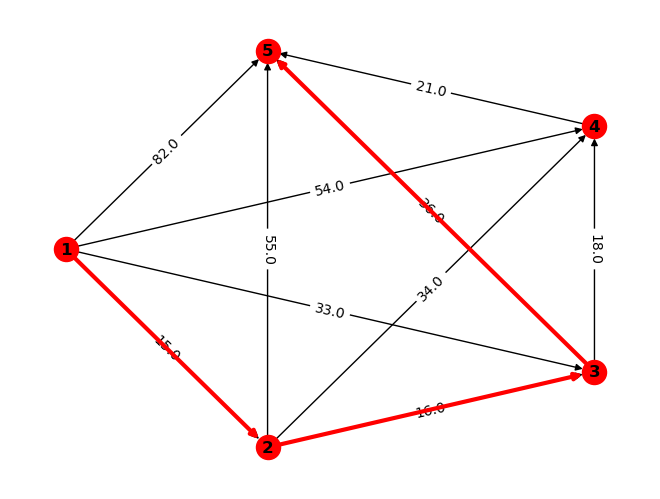

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

p = [25, 26, 28, 31]  # 购置价格
a = [10, 14, 18, 26]  # 维护费用
r = [20, 16, 13, 11]  # 净残值
b = np.zeros((5, 5))

# 邻接矩阵
for i in range(5):
    for j in range(i+1, 5):
        b[i][j] = p[i] + np.sum(a[0:j-i]) - r[j-i-1]
print(b)

G = nx.DiGraph(b)
p = nx.dijkstra_path(G, source=0, target=4, weight='weight')  # 求最短路径
print(f"最短路径为:\n{np.array(p)+1}")  # python的下标从0开始

d = nx.dijkstra_path_length(G, 0, 4, weight='weight')  # 求最短距离
print(f"所求的费用最小值为:\n{d}")
s = dict(zip(range(5), range(1, 6)))  # 构造用于顶点标注的标号字典

plt.rcParams['font.size'] = 16
pos = nx.shell_layout(G)  # 标号的位置
w = nx.get_edge_attributes(G, 'weight')
nx.draw(G, pos, font_weight='bold', labels=s, node_color='r')
nx.draw_networkx_edge_labels(G, pos, edge_labels=w)  # 添加边的权重
path_edges = list(zip(p, p[1:]))
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='r', width=3)  # 画出最短路线标红
plt.savefig("设备更新问题(Dijkstra算法).png", dpi=500)
plt.show()


In [49]:
# 使用Floyd算法
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

p = [25, 26, 28, 31]  # 购置价格
a = [10, 14, 18, 26]  # 维护费用
r = [20, 16, 13, 11]  # 净残值
b = np.zeros((5, 5))

# 邻接矩阵
for i in range(5):
    for j in range(i+1, 5):
        b[i][j] = p[i] + np.sum(a[0:j-i]) - r[j-i-1]

G = nx.Graph(b)
pred, distance= nx.floyd_warshall_predecessor_and_distance(G, weight='weight')

# 得到完整路径
def get_path(pred, u, v):
    if u == v:
        return [u]
    path = []
    current = v
    while current is not None:
        path.append(current)
        if current == u:
            break
        current = pred.get(u).get(current, None)  # 获取前驱节点
    else:
        return None  # No path found
    path.reverse()
    return path
    
path = get_path(pred, 0, 4)
print(f"最短路径为:\n{path}")
print(f"最短距离(最小费用)为:\n{np.array(distance[0][4])}")

最短路径为:
[0, 1, 2, 4]
最短距离(最小费用)为:
67.0


### 2. 重心问题(常用Dijkstra)

有些公共服务设施（例如邮局、学校等）的选址，要求设施到所有服务对象点的距离总和最小。一般要考虑人口密度问题，或者全体被服务对象来往的总路程最短。

某矿区有六个产矿点，如图 10.9 所示。已知各产矿点每天的产矿量（标在图 10.9 的各顶点旁）为 $q_i$ ($i = 1, 2, \cdots, 6$)，现要从这六个产矿点选一个来建造选矿厂，问应选在哪个产矿点，才能使各产矿点所产的矿石运到选矿厂所在地的总运力（t-km）最小。

**解**

令 $d_{ij}$ ($i, j = 1, 2, \cdots, 6$) 表示顶点 $v_i$ 与 $v_j$ 之间的距离。若选矿厂设在 $v_k$ 并且各产矿点到选矿厂的总运力为 $m_k$，则确定选矿厂的位置就转化为求 $m_k$，使得

$$
m_k = \min_{1 \leq i \leq 6} m_i.
$$

由于各产矿点到选矿厂的总运力依赖于任意两顶点之间的距离，即任意两顶点由于各产矿点到选矿厂的总运力依赖于任意两顶点之间的距离，即任意两顶点之间短路的长度，因此可首先利用 Dijkstra (或 Floyd) 算法求出所有顶点对之间的最短距离，然后计算出顶点 $v_i$ 作为设立选矿厂时各产矿点到 $v_i$ 的总运力

$$
m_i = \sum_{j=1}^6 q_j d_{ij}, \quad i = 1, 2, \cdots, 6.
$$

具体的计算结果见表 10.2。

### 表 10.2 各顶点对之间的最短距离和总运力计算数据

| 产矿点 | $v_1$ | $v_2$ | $v_3$ | $v_4$ | $v_5$ | $v_6$ | 总运力 $m_i$ |
|--------|-------|-------|-------|-------|-------|-------|---------------|
| $v_1$  | 0     | 20    | 25    | 55    | 15    | 30    | 4850          |
| $v_2$  | 20    | 0     | 20    | 40    | 25    | 40    | 4900          |
| $v_3$  | 25    | 20    | 0     | 30    | 10    | 25    | 5250          |
| $v_4$  | 55    | 40    | 30    | 0     | 40    | 55    | 11850         |
| $v_5$  | 15    | 25    | 10    | 40    | 0     | 15    | 4700          |
| $v_6$  | 30    | 40    | 25    | 55    | 15    | 0     | 8750          |

In [ ]:
import numpy as np
import networkx as nx

List = [(1, 2, 20), (1, 5, 15), (2, 3, 20), (2, 4, 40),
        (2, 5, 25), (3, 4, 30), (3, 5, 10), (5, 6, 15)]
G = nx.Graph()
G.add_nodes_from(range(1, 7))  # 点集1~6
G.add_weighted_edges_from(List)  # 边权

# c为{起点1: {终点1: distance, 终点2: distance, ...}, 起点2: {...} ... }
c = dict(nx.shortest_path_length(G, weight='weight'))  # 求最短距离，默认dijkstra算法
d = np.zeros((6, 6))

# 将字典(最短距离)转换为数组
for i in range(1, 7):
    for j in range(1, 7):
        d[i-1, j-1] = c[i][j]  # 字典用键索引，列表索引从0开始
print(d)

q = np.array([80, 90, 30, 20, 60, 10])  # 单位距离的运力
m = d @ q  # 计算运力，矩阵乘法,d(6, 6),q(6,)
mm = m.min()  # 求运力最小值
# m == mm返回布尔数组, np.where(m == mm)找到布尔数组值为True的元素的索引并返回
# np.where(m==mm)[0] 提取array([4],即输出[4]
ind = np.where(m==mm)[0] + 1  # python下标从0开始，np.where返回值为元组
# print(np.where(m==mm))  # 输出：(array([4], dtype=int64),)
print(f"运力m={m}\n最小运力mm={mm}\n选矿厂的设置位置为: {ind}")

[[ 0. 20. 25. 55. 15. 30.]
 [20.  0. 20. 40. 25. 40.]
 [25. 20.  0. 30. 10. 25.]
 [55. 40. 30.  0. 40. 55.]
 [15. 25. 10. 40.  0. 15.]
 [30. 40. 25. 55. 15.  0.]]
(array([4], dtype=int64),)
运力m=[ 4850.  4900.  5250. 11850.  4700.  8750.]
最小运力mm=4700.0
选矿厂的设置位置为: [5]
